# **Self-Supervised Learning**

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Clone the repository
!git clone https://github.com/sustainlab-group/SatMAE.git
%cd SatMAE

# Install dependencies
!pip install --break-system-packages timm==0.3.2
!pip install --break-system-packages wandb
!pip install --break-system-packages einops

Cloning into 'SatMAE'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 113 (delta 16), reused 12 (delta 9), pack-reused 83 (from 2)
Receiving objects: 100% (113/113), 10.94 MiB | 33.34 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/SatMAE
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.2/244.2 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.24
    Uninstalling timm-1.0.24:
      Successfully uninstalled timm-1.0.24


In [29]:
import math
import os
import sys
import time
import types
import json
import collections
import datetime
import importlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
import torch.nn.functional as F
import torch.optim as optim
import random
import rasterio
import matplotlib.pyplot as plt

from pathlib import Path
from argparse import Namespace
from functools import partial
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from rasterio.enums import Resampling
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score




In [4]:
# Monkey patch torch._six which was removed in PyTorch 2.0
# timm 0.3.2 relies on it.
# We unconditionally update it ensuring 'inf' is present.
if not hasattr(torch, '_six'):
    torch._six = types.ModuleType('torch._six')
    sys.modules['torch._six'] = torch._six

torch._six.container_abcs = collections.abc
torch._six.string_classes = (str,)
torch._six.int_classes = (int,)
torch._six.inf = torch.inf

sys.path.append('/content/SatMAE')

from models_mae_group_channels import mae_vit_large_patch16
import util.misc as misc

In [5]:
import models_mae_group_channels
import util.pos_embed

# --- Fix for deprecated np.float ---
# The repository file uses np.float which is removed in recent numpy versions.
# We patch it using sed.
os.system("sed -i 's/np.float/float/g' /content/SatMAE/util/pos_embed.py")
# Correct potential regression where np.float32 becomes float32
os.system("sed -i 's/dtype=float32/dtype=np.float32/g' /content/SatMAE/util/pos_embed.py")

# Reload the affected modules
importlib.reload(util.pos_embed)
importlib.reload(models_mae_group_channels)

<module 'models_mae_group_channels' from '/content/SatMAE/models_mae_group_channels.py'>

In [6]:
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [ ]:
class SentinelNormalize:
    """Match SatMAE's normalization exactly"""
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, x):
        # x shape: (C, H, W) as numpy array
        min_value = self.mean[:, None, None] - 2 * self.std[:, None, None]
        max_value = self.mean[:, None, None] + 2 * self.std[:, None, None]
        img = (x - min_value) / (max_value - min_value) * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)
        return img

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SSL Dataset for SatMAE
# ══════════════════════════════════════════════════════════════════════════════

class SatMAE_SSL_Dataset(Dataset):
    """
    Dataset for SatMAE SSL pretraining.
    Returns (image, 0) — masking is done by the model.
    """

    def __init__(self, unlabeled_dir, img_size=96, is_train=True, seed=42):
        self.img_size = img_size
        self.is_train = is_train
        self.band_names = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

        # Means and std calculated from SSL dataset
        self.mean = np.array([1451.5737, 1714.8955, 1955.1634, 2295.8645, 2822.0442,
                              3054.8946, 3181.4385, 3217.6201, 2697.5978, 2123.0536])
        self.std = np.array([2155.9483, 2041.8003, 2098.9490, 2068.6671, 1882.6053,
                             1830.5629, 1878.3066, 1745.6712, 1225.5768, 1120.5761])

        self.sentinel_normalize = SentinelNormalize(self.mean, self.std)
        self.transform = self._build_transform(is_train, img_size)

        # Load S2A samples
        self.samples = []
        if unlabeled_dir and os.path.exists(unlabeled_dir):
            print(f"📦 Loading S2A data from {unlabeled_dir}...")
            self.samples = self._load_s2a_data(Path(unlabeled_dir))
            print(f"✅ {len(self.samples)} samples loaded")
        else:
            raise ValueError(f"S2A data not found at {unlabeled_dir}")

        print(f"📊 SSL Dataset: {len(self.samples)} samples | {img_size}x{img_size} | {len(self.band_names)} bands | train={is_train}")

    def _build_transform(self, is_train, input_size):
        interp = transforms.InterpolationMode.BICUBIC
        t = [transforms.ToTensor()]
        if is_train:
            t.append(transforms.RandomResizedCrop(input_size, scale=(0.2, 1.0), interpolation=interp))
            t.append(transforms.RandomHorizontalFlip())
            t.append(transforms.RandomVerticalFlip())
        else:
            crop_pct = 224 / 256 if input_size <= 224 else 1.0
            t.append(transforms.Resize(int(input_size / crop_pct), interpolation=interp))
            t.append(transforms.CenterCrop(input_size))
        return transforms.Compose(t)

    def _load_s2a_data(self, s2a_root):
        samples = []
        locations = [d for d in s2a_root.iterdir() if d.is_dir()]
        print(f"   {len(locations)} locations found")
        for loc in tqdm(locations, desc="Loading S2A", leave=False):
            for acq in loc.iterdir():
                if acq.is_dir() and (acq / 'B2.tif').exists():
                    samples.append(acq)
        return samples

    def _load_image(self, sample_dir):
        bands = []
        for bname in self.band_names:
            path = sample_dir / f"{bname}.tif"
            try:
                with rasterio.open(path) as src:
                    band = src.read(1, out_shape=(256, 256), resampling=Resampling.bilinear)
            except Exception:
                band = np.zeros((256, 256), dtype='float32')
            bands.append(band)
        return np.stack(bands, axis=0).astype(np.float32)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = self._load_image(self.samples[idx])        # (C, H, W)
        img = self.sentinel_normalize(img)                # → [0, 255]
        img = img.astype(np.float32) / 255.0              # → [0, 1]
        img = np.transpose(img, (1, 2, 0))                # → (H, W, C)
        img_tensor = self.transform(img)                   # → (C, H, W) tensor
        return torch.clamp(img_tensor, 0.0, 1.0), 0


def get_ssl_dataloader(unlabeled_dir, batch_size=32, img_size=96, num_workers=0, seed=42):
    dataset = SatMAE_SSL_Dataset(unlabeled_dir=unlabeled_dir, img_size=img_size, is_train=True, seed=seed)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
    return loader, dataset

In [ ]:
import os
import subprocess
from google.colab import drive


# --- CONFIGURATION ---
ARCHIVE_PATH = '/content/drive/MyDrive/SSL/s2a.tar.gz'
EXTRACT_DIR = '/content/s2a_extracted'
# ---------------------

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR)

print(f"🚀 Starting extraction of 124GB file...")
print(f"📂 Source: {ARCHIVE_PATH}")
print(f"📂 Target: {EXTRACT_DIR}")
print("⏳ This process will take 30 minutes.\n")

try:
    subprocess.run(['tar', '-xf', ARCHIVE_PATH, '-C', EXTRACT_DIR], check=True)
    print("\n✅ Extraction COMPLETED successfully!")
    items = os.listdir(EXTRACT_DIR)
    print(f"📊 Extracted {len(items)} items/folders.")
    print(f"   First item: {items[0] if items else 'Empty'}")

except subprocess.CalledProcessError as e:
    print(f"\n❌ Extraction failed (Exit Code: {e.returncode})")
    print("   Common causes: Disk full on google colab")
except Exception as e:
    print(f"\n❌ Error: {e}")

🚀 Starting extraction of 124GB file...
📂 Source: /content/drive/MyDrive/SSL/s2a.tar.gz
📂 Target: /content/s2a_extracted
⏳ This process will take 30 minutes.


❌ Extraction failed (Exit Code: 2)
   Common causes: Disk full on google colab


In [ ]:
extract_path = '/content/s2a_extracted/s2a'

if os.path.exists(extract_path):
    files = os.listdir(extract_path)
    print(f"📂 Folder exists: {extract_path}")
    print(f"📄 Contains {len(files)} files/folders.")
    print(f"   Samples: {files[:5]}")

    # Check size of the extracted content
    total_size = sum(os.path.getsize(os.path.join(dirpath, filename))
                     for dirpath, _, filenames in os.walk(extract_path)
                     for filename in filenames)
    print(f"📊 Total Extracted Size: {total_size / (1024**3):.2f} GB")
else:
    print("❌ The folder 's2a' was not created.")

📂 Folder exists: /content/s2a_extracted/s2a
📄 Contains 24964 files/folders.
   Samples: ['041924', '006607', '004230', '030523', '004752']
📊 Total Extracted Size: 93.78 GB


In [ ]:
# ── Quick test ──
test_loader, test_ds = get_ssl_dataloader(
    unlabeled_dir='/content/s2a_extracted/s2a',
    batch_size=4, img_size=96, num_workers=0
)
imgs, _ = next(iter(test_loader))
print(f"Batch shape: {imgs.shape}")
print(f"Range: [{imgs.min():.3f}, {imgs.max():.3f}]")
del test_loader, test_ds

📦 Loading S2A data from /content/s2a_extracted/s2a...
   24964 locations found


Loading S2A:   0%|          | 0/24964 [00:00<?, ?it/s]

✅ 127728 samples loaded
📊 SSL Dataset: 127728 samples | 96x96 | 10 bands | train=True
Batch shape: torch.Size([4, 10, 96, 96])
Range: [0.033, 1.000]


In [ ]:
import os
from pathlib import Path
from tqdm.auto import tqdm

# Configuration
s2a_root = Path('/content/s2a_extracted/s2a')
required_bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

print(f"🔍 Checking for incomplete samples in {s2a_root}...")

incomplete_samples = []
total_samples = 0

if s2a_root.exists():
    locations = [d for d in s2a_root.iterdir() if d.is_dir()]

    for location in tqdm(locations, desc="Checking locations"):
        for acquisition in location.iterdir():
            if not acquisition.is_dir():
                continue

            total_samples += 1
            missing_bands = []
            for band in required_bands:
                if not (acquisition / f"{band}.tif").exists():
                    missing_bands.append(band)

            if missing_bands:
                incomplete_samples.append({
                    'path': str(acquisition),
                    'missing': missing_bands
                })

    print(f"\n📊 Summary:")
    print(f"   Total samples checked: {total_samples}")
    print(f"   Complete samples: {total_samples - len(incomplete_samples)}")
    print(f"   Incomplete samples: {len(incomplete_samples)}")

    if incomplete_samples:
        print(f"\n⚠️ First 5 incomplete samples:")
        for sample in incomplete_samples[:5]:
            print(f"   {sample['path']}")
            print(f"   -> Missing: {sample['missing']}")
else:
    print(f"❌ Directory {s2a_root} not found.")

🔍 Checking for incomplete samples in /content/s2a_extracted/s2a...


Checking locations:   0%|          | 0/24964 [00:00<?, ?it/s]


📊 Summary:
   Total samples checked: 127728
   Complete samples: 127727
   Incomplete samples: 1

⚠️ First 5 incomplete samples:
   /content/s2a_extracted/s2a/019233/20200916T180011_20200916T180205_T13UFR
   -> Missing: ['B6', 'B7', 'B8', 'B8A', 'B11', 'B12']


In [ ]:
import shutil
from pathlib import Path

sample_to_remove = Path('/content/s2a_extracted/s2a/019233/20200916T180011_20200916T180205_T13UFR')

if sample_to_remove.exists():
    print(f"🗑️ Removing {sample_to_remove}...")
    shutil.rmtree(sample_to_remove)
    print("✅ Sample removed successfully.")
else:
    print("⚠️ Sample not found (maybe already removed).")

🗑️ Removing /content/s2a_extracted/s2a/019233/20200916T180011_20200916T180205_T13UFR...
✅ Sample removed successfully.


**Model with Freezing Strategy**

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════════════════════════════════

def get_ssl_config():
    cfg = Namespace(
        # ── Paths ──
        unlabeled_dir='/content/s2a_extracted/s2a',
        checkpoint_path='/content/drive/MyDrive/SSL/pretrain-vit-large-e199.pth',
        output_dir='/content/drive/MyDrive/SSL/ssl_checkpoints_127814',

        # ── Model ──
        model_name='mae_vit_large_patch16',
        img_size=96,
        patch_size=8,
        in_chans=10,
        grouped_bands=[[0, 1, 2, 6], [3, 4, 5, 7], [8, 9]],

        # ── Freezing ──
        freeze_patch_embed=True,
        freeze_encoder_blocks_up_to=5,  # train blocks 6-23
        train_full_decoder=True,

        # ── Training ──
        epochs=80,
        warmup_epochs=5,
        batch_size=32,
        accum_iter=8,           # Adjusted to keep 256 effective batch size
        blr=1.5e-4,             # Base LR
        layer_decay=0.80,       # LLRD for stability
        min_lr=1e-6,
        weight_decay=0.05,
        clip_grad=1.0,          # gradient clipping for safety

        # ── MAE ──
        mask_ratio=0.75,
        spatial_mask=False,
        norm_pix_loss=False,

        # ── Resume ──
        resume_mode='full',

        # ── Visualization ──
        viz_every=10,
        viz_num_images=4,
        viz_rgb_bands=[2, 1, 0],
        viz_save=True,

        # ── Misc ──
        seed=42,
        num_workers=4,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        save_every=10,
        print_freq=20,
        use_wandb=True,
        wandb_project='satmae-ssl-127814',
    )

    eff_batch = cfg.batch_size * cfg.accum_iter
    cfg.lr = cfg.blr * eff_batch / 256
    print(f"Effective batch: {eff_batch} | Base LR: {cfg.blr:.2e} → Actual LR: {cfg.lr:.2e}")
    return cfg


# ══════════════════════════════════════════════════════════════════════════════
# Build model + apply freezing
# ══════════════════════════════════════════════════════════════════════════════

def apply_freezing(model, cfg):
    # Freeze everything first
    for p in model.parameters():
        p.requires_grad = False

    n_blocks = len(model.blocks)
    unfreeze_from = cfg.freeze_encoder_blocks_up_to + 1
    for i in range(unfreeze_from, n_blocks):
        for p in model.blocks[i].parameters():
            p.requires_grad = True

    # Unfreeze encoder final LayerNorm
    for p in model.norm.parameters():
        p.requires_grad = True

    # Unfreeze full decoder
    if cfg.train_full_decoder:
        for name, p in model.named_parameters():
            if 'decoder' in name or 'mask_token' in name:
                p.requires_grad = True

    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = frozen + trainable
    print(f"\n🔒 Frozen encoder blocks: 0..{cfg.freeze_encoder_blocks_up_to}")
    print(f"🔓 Trainable encoder blocks: {unfreeze_from}..{n_blocks - 1} + decoder")
    print(f"📊 Frozen: {frozen:,} ({frozen/total*100:.1f}%) | Trainable: {trainable:,} ({trainable/total*100:.1f}%) | Total: {total:,}")


def build_model(cfg):
    device = torch.device(cfg.device)

    print(f"\n🏗️  {cfg.model_name} | img={cfg.img_size} | patch={cfg.patch_size}")
    model = models_mae_group_channels.__dict__[cfg.model_name](
        img_size=cfg.img_size,
        patch_size=cfg.patch_size,
        in_chans=cfg.in_chans,
        channel_groups=cfg.grouped_bands,
        spatial_mask=cfg.spatial_mask,
        norm_pix_loss=cfg.norm_pix_loss,
    )

    # Load pretrained weights
    if cfg.checkpoint_path and os.path.exists(cfg.checkpoint_path):
        print(f"⬇️  Loading: {cfg.checkpoint_path}")
        ckpt = torch.load(cfg.checkpoint_path, map_location='cpu', weights_only=False)
        state_dict = ckpt['model'] if 'model' in ckpt else ckpt
        msg = model.load_state_dict(state_dict, strict=False)
        print(f"✅ Loaded. Missing: {len(msg.missing_keys)} | Unexpected: {len(msg.unexpected_keys)}")
    else:
        print("⚠️  No checkpoint found — training from scratch!")

    apply_freezing(model, cfg)
    model.to(device)
    return model

**Optimizer & LR Schedule**

In [ ]:
def get_parameter_groups(model, cfg):
    """
    Create parameter groups with Layer-wise Learning Rate Decay (LLRD).

    Lower layers get smaller LR to prevent catastrophic forgetting.
    Higher layers get larger LR for task-specific adaptation.
    """
    # Skip list for params without weight decay
    skip_list = set()
    if hasattr(model, 'no_weight_decay'):
        skip_list = model.no_weight_decay()

    parameter_groups = {}

    # Calculate total number of layers (24 encoder blocks + 1 for embeddings)
    num_layers = len(model.blocks) + 1
    layer_decay = cfg.layer_decay

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue  # Skip frozen parameters

        # ── Determine layer ID ──
        if name.startswith('cls_token') or name.startswith('pos_embed') or name.startswith('patch_embed'):
            layer_id = 0
        elif name.startswith('blocks'):
            # Extract block index: "blocks.15.attn.qkv.weight" → 15
            layer_id = int(name.split('.')[1]) + 1
        else:
            # Decoder, final norm, mask token → highest layer ID
            layer_id = num_layers

        # ── Calculate LR scale ──
        # Higher layers (close to output) → scale ≈ 1.0
        # Lower layers (close to input) → scale ≈ layer_decay^(num_layers - layer_id)
        scale = layer_decay ** (num_layers - layer_id)

        # ── Determine weight decay ──
        # No decay for: biases, 1D params (LayerNorm), params in skip_list
        if len(param.shape) == 1 or name.endswith(".bias") or name in skip_list:
            group_name = "no_decay"
            this_weight_decay = 0.0
        else:
            group_name = "decay"
            this_weight_decay = cfg.weight_decay

        # ── Group by (decay type, lr_scale, weight_decay) ──
        group_key = (group_name, scale, this_weight_decay)

        if group_key not in parameter_groups:
            parameter_groups[group_key] = {
                'params': [],
                'weight_decay': this_weight_decay,
                'lr_scale': scale,  # Store scale for adjust_learning_rate
            }
        parameter_groups[group_key]['params'].append(param)

    # ── Convert to PyTorch optimizer format ──
    param_groups = []
    print("\n⚙️  Parameter Groups (LLRD):")
    for (name, scale, wd), group_dict in sorted(parameter_groups.items()):
        actual_lr = cfg.lr * scale
        param_groups.append({
            'params': group_dict['params'],
            'weight_decay': wd,
            'lr': actual_lr,
            'lr_scale': scale,  # Keep for cosine schedule adjustment
        })
        n_params = sum(p.numel() for p in group_dict['params'])
        print(f"   {name:10s} | scale={scale:.4f} | lr={actual_lr:.2e} | params={n_params:,}")

    return param_groups


def build_optimizer(model, cfg):
    """Build AdamW optimizer with Layer-wise Learning Rate Decay."""
    param_groups = get_parameter_groups(model, cfg)

    optimizer = torch.optim.AdamW(param_groups, betas=(0.9, 0.95))

    total_params = sum(p.numel() for group in param_groups for p in group['params'])
    print(f"\n✅ AdamW created | Total trainable params: {total_params:,}")
    return optimizer


def adjust_learning_rate(optimizer, epoch, cfg):
    """
    Cosine decay with linear warmup.
    Respects lr_scale for each parameter group (LLRD).
    """
    if epoch < cfg.warmup_epochs:
        lr = cfg.lr * epoch / cfg.warmup_epochs
    else:
        progress = (epoch - cfg.warmup_epochs) / (cfg.epochs - cfg.warmup_epochs)
        lr = cfg.min_lr + (cfg.lr - cfg.min_lr) * 0.5 * (1.0 + math.cos(math.pi * progress))

    # Apply to all groups, respecting their lr_scale
    for pg in optimizer.param_groups:
        pg['lr'] = lr * pg.get('lr_scale', 1.0)

    return lr



**Reconstruction Visualization**

In [ ]:
def pred_to_image(pred, patch_size, img_size):
    """
    Convert model prediction back to image space.

    pred: (N, C, L, p^2) from model.forward_decoder
    Returns: (N, C, H, W)
    """
    N, C, L, pp = pred.shape
    p = patch_size
    h = w = int(L ** 0.5)
    assert h * w == L, f"Patches {L} don't form a square grid"

    # (N, C, L, p^2) -> (N, C, h, w, p, p) -> (N, C, H, W)
    pred = pred.reshape(N, C, h, w, p, p)
    imgs = pred.permute(0, 1, 2, 4, 3, 5).contiguous()
    imgs = imgs.reshape(N, C, h * p, w * p)
    return imgs


def mask_to_image(mask, patch_size, img_size, channel_groups, in_chans):
    """
    Expand patch-level mask to pixel-level per channel.

    mask: (N, G, L) where G=num_groups, 0=visible, 1=masked
    Returns: (N, C, H, W) binary mask, 1=masked
    """
    N, G, L = mask.shape
    p = patch_size
    h = w = int(L ** 0.5)

    # Expand groups to per-channel: (N, G, L) -> (N, C, L)
    channel_mask = torch.zeros(N, in_chans, L, device=mask.device)
    for g, group in enumerate(channel_groups):
        for c in group:
            channel_mask[:, c, :] = mask[:, g, :]

    # Expand patches to pixels: (N, C, L) -> (N, C, h, w) -> (N, C, H, W)
    channel_mask = channel_mask.reshape(N, in_chans, h, w)
    # Repeat each patch value across p x p pixels
    channel_mask = channel_mask.repeat_interleave(p, dim=2).repeat_interleave(p, dim=3)
    return channel_mask


@torch.no_grad()
def visualize_reconstruction(model, dataloader, device, epoch, cfg):
    """
    Run model on a batch, plot:
      Row 1: Original (RGB)
      Row 2: Masked input (visible patches only)
      Row 3: Reconstruction (predicted patches only)
      Row 4: Composite (visible original + predicted masked regions)

    Uses B4/B3/B2 (indices 2,1,0) as RGB for display.
    """
    model.eval()

    # Get a batch
    samples, _ = next(iter(dataloader))
    samples = samples.to(device)

    n_show = min(cfg.viz_num_images, samples.shape[0])
    rgb_idx = cfg.viz_rgb_bands  # [2, 1, 0] = B4, B3, B2

    # Forward pass
    loss, pred, mask = model(samples, mask_ratio=cfg.mask_ratio)
    # pred: (N, C, L, p^2)
    # mask: (N, G, L) — 0=visible, 1=masked

    # Reconstruct predicted image
    pred_img = pred_to_image(pred, cfg.patch_size, cfg.img_size)  # (N, C, H, W)

    # Expand mask to pixel level
    pixel_mask = mask_to_image(
        mask, cfg.patch_size, cfg.img_size,
        cfg.grouped_bands, cfg.in_chans
    )  # (N, C, H, W) — 1=masked

    # Move to CPU numpy
    orig = samples[:n_show].cpu().numpy()          # (n, C, H, W)
    recon = pred_img[:n_show].cpu().numpy()         # (n, C, H, W)
    pmask = pixel_mask[:n_show].cpu().numpy()       # (n, C, H, W)

    # ── Build display images (RGB only) ──
    # Original RGB
    orig_rgb = orig[:, rgb_idx, :, :]              # (n, 3, H, W)

    # Masked input: show visible patches, gray out masked
    masked_rgb = orig_rgb.copy()
    mask_rgb = pmask[:, rgb_idx, :, :]             # (n, 3, H, W)
    masked_rgb[mask_rgb == 1] = 0.5                # gray for masked regions

    # Reconstruction: show only predicted (masked) patches, gray for visible
    recon_rgb = np.full_like(orig_rgb, 0.5)        # gray background
    recon_only = recon[:, rgb_idx, :, :]
    recon_rgb[mask_rgb == 1] = np.clip(recon_only[mask_rgb == 1], 0, 1)

    # Composite: original visible + predicted masked
    composite_rgb = orig_rgb.copy()
    composite_rgb[mask_rgb == 1] = np.clip(recon_only[mask_rgb == 1], 0, 1)

    # ── Plot ──
    fig, axes = plt.subplots(4, n_show, figsize=(4 * n_show, 14))
    if n_show == 1:
        axes = axes[:, np.newaxis]  # ensure 2D indexing

    row_labels = ['Original', 'Masked Input', 'Reconstruction\n(predicted only)', 'Composite']
    all_rows = [orig_rgb, masked_rgb, recon_rgb, composite_rgb]

    for row_idx, (label, images) in enumerate(zip(row_labels, all_rows)):
        for col_idx in range(n_show):
            ax = axes[row_idx, col_idx]
            # (3, H, W) -> (H, W, 3)
            img_display = np.transpose(images[col_idx], (1, 2, 0))
            img_display = np.clip(img_display, 0, 1)
            ax.imshow(img_display)
            ax.axis('off')
            if col_idx == 0:
                ax.set_ylabel(label, fontsize=12, fontweight='bold', rotation=0,
                              labelpad=100, va='center')
            if row_idx == 0:
                ax.set_title(f'Sample {col_idx + 1}', fontsize=11)

    fig.suptitle(
        f'Epoch {epoch} | Loss: {loss.item():.4f} | Mask: {cfg.mask_ratio*100:.0f}% | '
        f'RGB = B4/B3/B2',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()

    # Save
    if cfg.viz_save:
        viz_dir = os.path.join(cfg.output_dir, 'reconstructions')
        os.makedirs(viz_dir, exist_ok=True)
        save_path = os.path.join(viz_dir, f'recon_epoch_{epoch:04d}.png')
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"   Saved: {save_path}")

    plt.show()
    plt.close(fig)

    model.train()
    return loss.item()

In [ ]:
def check_layer_drift(model, initial_state, epoch, cfg):
    """
    Monitor how much ALL layers have drifted from initial pretrained weights.
    Plots drift across all blocks for visual analysis.
    """
    if epoch % 10 != 0 and epoch != 0:
        return

    n_blocks = len(model.blocks)
    drifts = []

    # Calculate drift for all blocks
    for i in range(n_blocks):
        current = model.blocks[i].attn.qkv.weight
        initial_key = f'blocks.{i}.attn.qkv.weight'

        if initial_key not in initial_state:
            continue

        initial = initial_state[initial_key]
        diff = (current - initial).abs().mean()
        rel_change = (diff / initial.abs().mean()) * 100
        drifts.append(rel_change.item())

    # 🎯 Compact console summary (instead of printing all 24 blocks)
    print(f"\n📊 Layer Drift @ Epoch {epoch}:")
    print(f"   Bottom (0-5):   {np.mean(drifts[:6]):.3f}% ± {np.std(drifts[:6]):.3f}")
    print(f"   Middle (6-17):  {np.mean(drifts[6:18]):.3f}% ± {np.std(drifts[6:18]):.3f}")
    print(f"   Top (18-23):    {np.mean(drifts[18:]):.3f}% ± {np.std(drifts[18:]):.3f}")
    print(f"   Overall:        {np.mean(drifts):.3f}% (max: {np.max(drifts):.3f}%)")

    # 🆕 Enhanced visualization with TWO subplots
    if cfg.viz_save:
        import matplotlib.pyplot as plt

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Left: Per-block drift (detailed)
        ax1.bar(range(n_blocks), drifts, color='steelblue', alpha=0.7)
        ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='1% threshold')
        ax1.axhline(y=5.0, color='orange', linestyle='--', linewidth=1, label='5% threshold')
        ax1.set_xlabel('Block Index', fontsize=11)
        ax1.set_ylabel('Weight Drift (%)', fontsize=11)
        ax1.set_title('Per-Block Drift', fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)

        # Right: Grouped comparison (summary)
        groups = ['Bottom\n(0-5)', 'Middle\n(6-17)', 'Top\n(18-23)']
        group_drifts = [
            np.mean(drifts[:6]),
            np.mean(drifts[6:18]),
            np.mean(drifts[18:])
        ]
        group_stds = [
            np.std(drifts[:6]),
            np.std(drifts[6:18]),
            np.std(drifts[18:])
        ]

        ax2.bar(groups, group_drifts, yerr=group_stds, capsize=5,
                color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.7)
        ax2.set_ylabel('Mean Weight Drift (%)', fontsize=11)
        ax2.set_title('Grouped Drift Comparison', fontsize=12, fontweight='bold')
        ax2.grid(axis='y', alpha=0.3)

        fig.suptitle(f'Layer Drift Analysis - Epoch {epoch}',
                     fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()

        # Save
        drift_dir = os.path.join(cfg.output_dir, 'drift_analysis')
        os.makedirs(drift_dir, exist_ok=True)
        save_path = os.path.join(drift_dir, f'drift_epoch_{epoch:04d}.png')
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"   💾 Saved: {save_path}\n")
        plt.close(fig)

        # Log to W&B
        if cfg.use_wandb:
            import wandb
            wandb.log({
                'drift/mean': np.mean(drifts),
                'drift/max': np.max(drifts),
                'drift/bottom': group_drifts[0],    # Changed key name
                'drift/middle': group_drifts[1],    # Changed key name
                'drift/top': group_drifts[2],       # Changed key name
                'epoch': epoch,
            })

**Training Loop**

In [ ]:
import wandb
def train_one_epoch(model, dataloader, optimizer, device, epoch, loss_scaler, cfg):
    model.train()
    total_loss = 0.0
    n_batches = 0
    optimizer.zero_grad()

    for step, (samples, _) in enumerate(dataloader):
        # Per-iteration LR schedule
        if step % cfg.accum_iter == 0:
            adjust_learning_rate(optimizer, step / len(dataloader) + epoch, cfg)

        samples = samples.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            loss, _, _ = model(samples, mask_ratio=cfg.mask_ratio)

        loss_val = loss.item()

        if not math.isfinite(loss_val):
            print(f"  ⚠️ Loss={loss_val} at step {step}, skipping")
            optimizer.zero_grad()
            continue

        loss = loss / cfg.accum_iter

        if loss_scaler is not None:
            loss_scaler(
                loss, optimizer,
                clip_grad=cfg.clip_grad,  # Use config value
                parameters=[p for p in model.parameters() if p.requires_grad],
                update_grad=(step + 1) % cfg.accum_iter == 0,
            )
        else:
            loss.backward()
            if (step + 1) % cfg.accum_iter == 0:
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad],
                    cfg.clip_grad
                )
                optimizer.step()

        if (step + 1) % cfg.accum_iter == 0:
            optimizer.zero_grad()

        total_loss += loss_val
        n_batches += 1

        if step % cfg.print_freq == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"  [{step:4d}/{len(dataloader)}] loss={loss_val:.4f} avg={total_loss/n_batches:.4f} lr={lr:.2e}")

            if cfg.use_wandb:
                wandb.log({
                    'train_loss_step': loss_val,
                    'lr_step': lr,
                    'epoch': epoch + (step / len(dataloader))
                })
    return {'loss': total_loss / max(n_batches, 1), 'lr': optimizer.param_groups[0]['lr']}


def save_checkpoint(model, optimizer, loss_scaler, epoch, cfg, loss):
    os.makedirs(cfg.output_dir, exist_ok=True)
    save_dict = {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch,
        'loss': loss,
        'config': vars(cfg),
    }
    if loss_scaler is not None:
        save_dict['scaler'] = loss_scaler.state_dict()

    path = os.path.join(cfg.output_dir, f'ssl_ckpt_ep{epoch:04d}.pth')
    torch.save(save_dict, path)
    torch.save(save_dict, os.path.join(cfg.output_dir, 'ssl_ckpt_latest.pth'))
    print(f"💾 Saved: {path}")

def resume_from_checkpoint(model, optimizer, loss_scaler, cfg):
    latest = os.path.join(cfg.output_dir, 'ssl_ckpt_latest.pth')

    if cfg.resume_mode == 'none':
        print("resume_mode='none' -> starting fresh from fMoW pretrained weights")
        return 0

    if not os.path.exists(latest):
        print(f"No checkpoint at {latest} -> starting from epoch 0")
        return 0

    print(f"\nLoading checkpoint: {latest}")
    ckpt = torch.load(latest, map_location='cpu', weights_only=False)
    prev_epoch = ckpt['epoch']
    prev_loss = ckpt.get('loss', -1)
    prev_config = ckpt.get('config', {})

    if cfg.resume_mode == 'full':
        print(f"resume_mode='full' -> restoring model + optimizer + scaler")
        model.load_state_dict(ckpt['model'], strict=True)
        optimizer.load_state_dict(ckpt['optimizer'])
        if loss_scaler is not None and 'scaler' in ckpt:
            loss_scaler.load_state_dict(ckpt['scaler'])
        start_epoch = prev_epoch + 1
        print(f"   Resuming from epoch {start_epoch} (prev loss={prev_loss:.4f})")
        return start_epoch

    if cfg.resume_mode == 'model_only':
        print(f"resume_mode='model_only' -> restoring model weights, FRESH optimizer")
        model.load_state_dict(ckpt['model'], strict=True)
        start_epoch = prev_epoch + 1

        prev_blr = prev_config.get('blr', '?')
        prev_lr = prev_config.get('lr', '?')
        prev_wd = prev_config.get('weight_decay', '?')
        prev_freeze = prev_config.get('freeze_encoder_blocks_up_to', '?')
        prev_epochs = prev_config.get('epochs', '?')

        print(f"   Model from epoch {prev_epoch} (loss={prev_loss:.4f})")
        print(f"   Optimizer is FRESH")
        print(f"")
        print(f"   Config comparison:")
        print(f"   {'':22s} {'Previous':>12s}  {'Current':>12s}")
        print(f"   {'base_lr':22s} {str(prev_blr):>12s}  {cfg.blr:>12.2e}")
        print(f"   {'actual_lr':22s} {str(prev_lr):>12s}  {cfg.lr:>12.2e}")
        print(f"   {'weight_decay':22s} {str(prev_wd):>12s}  {cfg.weight_decay:>12.4f}")
        print(f"   {'freeze_up_to':22s} {str(prev_freeze):>12s}  {cfg.freeze_encoder_blocks_up_to:>12d}")
        print(f"   {'epochs':22s} {str(prev_epochs):>12s}  {cfg.epochs:>12d}")
        return start_epoch

    raise ValueError(f"Unknown resume_mode='{cfg.resume_mode}'")


def load_checkpoint(model, optimizer, loss_scaler, cfg):
    latest = os.path.join(cfg.output_dir, 'ssl_ckpt_latest.pth')
    if not os.path.exists(latest):
        return 0
    print(f"🔄 Resuming from {latest}")
    ckpt = torch.load(latest, map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model'], strict=True)
    optimizer.load_state_dict(ckpt['optimizer'])
    if loss_scaler is not None and 'scaler' in ckpt:
        loss_scaler.load_state_dict(ckpt['scaler'])
    start = ckpt['epoch'] + 1
    print(f"   Resuming epoch {start} (prev loss={ckpt.get('loss', '?'):.4f})")
    return start

In [ ]:
def train_ssl(cfg=None):
    if cfg is None:
        cfg = get_ssl_config()

    device = torch.device(cfg.device)
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)
    if device.type == 'cuda':
        cudnn.benchmark = True

    # Data
    ssl_loader, ssl_dataset = get_ssl_dataloader(
        unlabeled_dir=cfg.unlabeled_dir,
        batch_size=cfg.batch_size,
        img_size=cfg.img_size,
        num_workers=cfg.num_workers,
        seed=cfg.seed,
    )
    print(f"Batches/epoch: {len(ssl_loader)}")

    if cfg.checkpoint_path and os.path.exists(cfg.checkpoint_path):
        pretrained_ckpt = torch.load(cfg.checkpoint_path, map_location='cpu', weights_only=False)
        pretrained_state = pretrained_ckpt['model'] if 'model' in pretrained_ckpt else pretrained_ckpt

        # Store only the attention weights from all blocks for drift monitoring
        initial_state = {}
        for name in pretrained_state.keys():
            if 'blocks' in name and 'attn.qkv.weight' in name:
                initial_state[name] = pretrained_state[name].clone().detach().to(device)

        print(f"   ✅ Stored {len(initial_state)} original pretrained layer weights")
        print(f"   📍 These weights are from: {cfg.checkpoint_path}")
        print(f"   🎯 Drift will ALWAYS be measured against these original weights\n")
    else:
        print(f"   ⚠️  No pretrained checkpoint found at {cfg.checkpoint_path}")
        print(f"   ⚠️  Drift monitoring will be disabled\n")
        initial_state = None

    # Model
    model = build_model(cfg)

    # Optimizer
    optimizer = build_optimizer(model, cfg)

    # Loss scaler
    loss_scaler = misc.NativeScalerWithGradNormCount() if device.type == 'cuda' else None

    # Resume
    # start_epoch = load_checkpoint(model, optimizer, loss_scaler, cfg)
    start_epoch = resume_from_checkpoint(model, optimizer, loss_scaler, cfg)
    if start_epoch >= cfg.epochs:
        print(f"\nstart_epoch ({start_epoch}) >= epochs ({cfg.epochs})")
        print(f"Increase cfg.epochs or use resume_mode='none'")
        return model, []

    # W&B (optional)
    if cfg.use_wandb:
        import wandb
        wandb.init(project=cfg.wandb_project, config=vars(cfg))

    # ── Visualization: initial state before training ──
    print("\nVisualization: epoch 0 (before training)")
    visualize_reconstruction(model, ssl_loader, device, start_epoch, cfg)

    # Train
    print(f"\n{'='*60}")
    print(f"Training epochs {start_epoch}..{cfg.epochs-1}")
    print(f"   LR: {cfg.lr:.2e} -> {cfg.min_lr:.2e} (cosine + {cfg.warmup_epochs}ep warmup)")
    print(f"   Mask: {cfg.mask_ratio} | Resume: {cfg.resume_mode}")
    print(f"   Viz every: {cfg.viz_every} epochs")
    print(f"{'='*60}\n")

    best_loss = float('inf')
    history = []

    for epoch in range(start_epoch, cfg.epochs):
        t0 = time.time()
        stats = train_one_epoch(model, ssl_loader, optimizer, device, epoch, loss_scaler, cfg)
        elapsed = time.time() - t0

        ep_loss = stats['loss']
        history.append({'epoch': epoch, **stats, 'time': elapsed})

        print(f"\n📈 Epoch {epoch:3d}/{cfg.epochs} | Loss={ep_loss:.4f} | LR={stats['lr']:.2e} | {elapsed:.0f}s")

        # 🎯 Check drift against ORIGINAL pretrained weights
        if initial_state is not None:
            check_layer_drift(model, initial_state, epoch, cfg)

        # ── Visualization every N epochs ──
        if (epoch + 1) % cfg.viz_every == 0 or epoch == cfg.epochs - 1:
            print(f"\n--- Reconstruction @ Epoch {epoch} ---")
            visualize_reconstruction(model, ssl_loader, device, epoch, cfg)

        # ── Checkpoint ──
        if ep_loss < best_loss:
            best_loss = ep_loss
            save_checkpoint(model, optimizer, loss_scaler, epoch, cfg, ep_loss)
            print(f"   ⭐ New best!")
        elif (epoch + 1) % cfg.save_every == 0:
            save_checkpoint(model, optimizer, loss_scaler, epoch, cfg, ep_loss)

        if cfg.use_wandb:
            wandb.log({'epoch': epoch, 'train_loss': ep_loss, 'lr': stats['lr']})

    # Final save
    save_checkpoint(model, optimizer, loss_scaler, cfg.epochs - 1, cfg, history[-1]['loss'])

    # Save history
    hist_path = os.path.join(cfg.output_dir, 'training_history.json')
    with open(hist_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"\n🏆 Best loss: {best_loss:.4f}")
    print(f"📊 History: {hist_path}")

    return model, history

Effective batch: 256 | Base LR: 1.50e-04 → Actual LR: 1.50e-04
📦 Loading S2A data from /content/s2a_extracted/s2a...
   24964 locations found


Loading S2A:   0%|          | 0/24964 [00:00<?, ?it/s]

✅ 127727 samples loaded
📊 SSL Dataset: 127727 samples | 96x96 | 10 bands | train=True
Batches/epoch: 3991
   ✅ Stored 32 original pretrained layer weights
   📍 These weights are from: /content/drive/MyDrive/SSL/pretrain-vit-large-e199.pth
   🎯 Drift will ALWAYS be measured against these original weights


🏗️  mae_vit_large_patch16 | img=96 | patch=8
⬇️  Loading: /content/drive/MyDrive/SSL/pretrain-vit-large-e199.pth
✅ Loaded. Missing: 0 | Unexpected: 0

🔒 Frozen encoder blocks: 0..5
🔓 Trainable encoder blocks: 6..23 + decoder
📊 Frozen: 76,348,928 (23.2%) | Trainable: 252,864,000 (76.8%) | Total: 329,212,928

⚙️  Parameter Groups (LLRD):
   decay      | scale=0.0180 | lr=2.70e-06 | params=12,582,912
   decay      | scale=0.0225 | lr=3.38e-06 | params=12,582,912
   decay      | scale=0.0281 | lr=4.22e-06 | params=12,582,912
   decay      | scale=0.0352 | lr=5.28e-06 | params=12,582,912
   decay      | scale=0.0440 | lr=6.60e-06 | params=12,582,912
   decay      | scale=0.0550 | lr=8.25e-

/content/SatMAE/util/misc.py:251: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()


resume_mode='full' -> restoring model + optimizer + scaler
   Resuming from epoch 71 (prev loss=0.0009)


...

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sokkungsamreth (sokkungsamreth-imt-mines-al-s) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



Visualization: epoch 0 (before training)
   Saved: /content/drive/MyDrive/SSL/ssl_checkpoints_127814/reconstructions/recon_epoch_0071.png


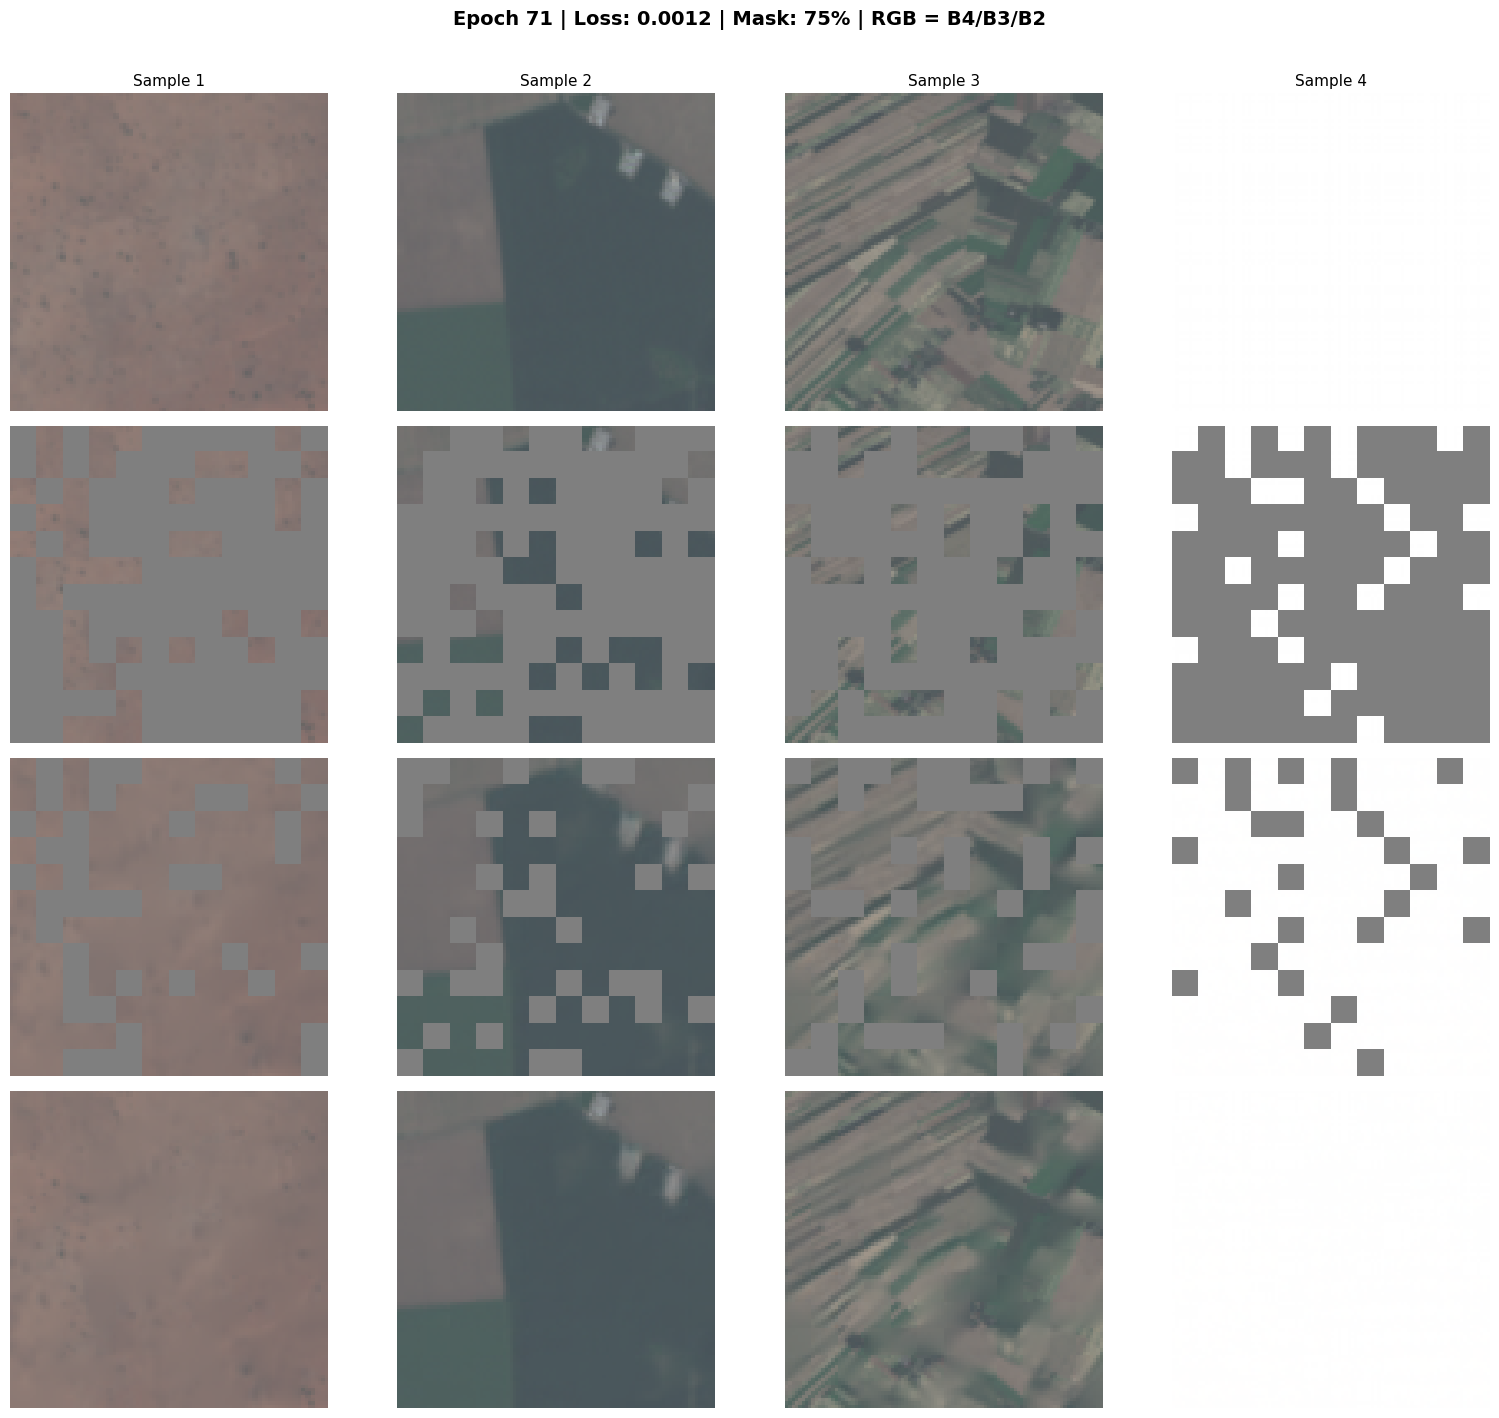


Training epochs 71..79
   LR: 1.50e-04 -> 1.00e-06 (cosine + 5ep warmup)
   Mask: 0.75 | Resume: full
   Viz every: 10 epochs



/tmp/ipython-input-2345697228.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


  [   0/3991] loss=0.0009 avg=0.0009 lr=1.12e-07
  [  20/3991] loss=0.0015 avg=0.0010 lr=1.12e-07
  [  40/3991] loss=0.0009 avg=0.0010 lr=1.12e-07
  [  60/3991] loss=0.0008 avg=0.0009 lr=1.12e-07
  [  80/3991] loss=0.0008 avg=0.0009 lr=1.12e-07
  [ 100/3991] loss=0.0008 avg=0.0009 lr=1.12e-07
  [ 120/3991] loss=0.0008 avg=0.0009 lr=1.12e-07
  [ 140/3991] loss=0.0008 avg=0.0009 lr=1.12e-07
  [ 160/3991] loss=0.0009 avg=0.0009 lr=1.11e-07
  [ 180/3991] loss=0.0012 avg=0.0009 lr=1.11e-07
  [ 200/3991] loss=0.0010 avg=0.0009 lr=1.11e-07
  [ 220/3991] loss=0.0007 avg=0.0009 lr=1.11e-07
  [ 240/3991] loss=0.0009 avg=0.0009 lr=1.11e-07
  [ 260/3991] loss=0.0007 avg=0.0009 lr=1.11e-07
  [ 280/3991] loss=0.0010 avg=0.0009 lr=1.11e-07
  [ 300/3991] loss=0.0006 avg=0.0009 lr=1.11e-07
  [ 320/3991] loss=0.0010 avg=0.0009 lr=1.11e-07
  [ 340/3991] loss=0.0009 avg=0.0009 lr=1.11e-07
  [ 360/3991] loss=0.0010 avg=0.0009 lr=1.10e-07
  [ 380/3991] loss=0.0012 avg=0.0009 lr=1.10e-07
  [ 400/3991] loss=0

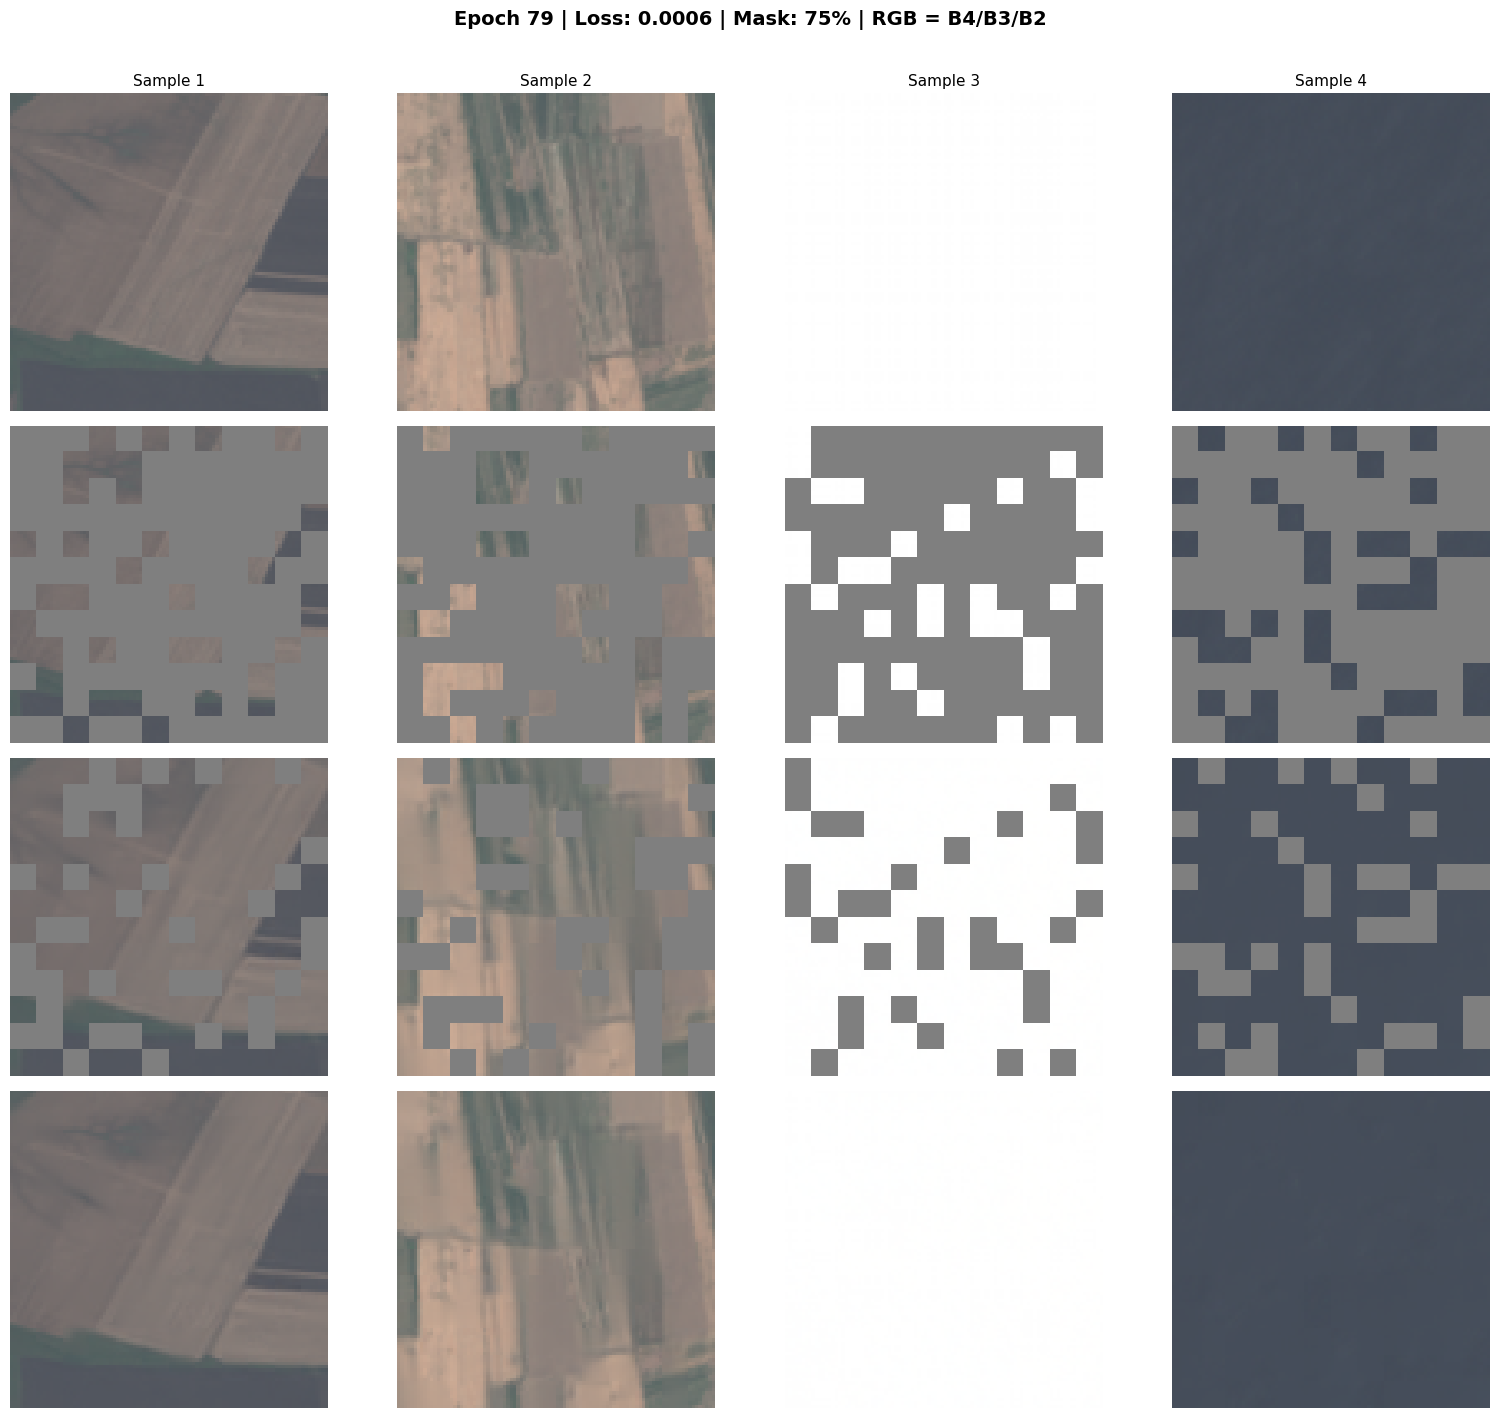

💾 Saved: /content/drive/MyDrive/SSL/ssl_checkpoints_127814/ssl_ckpt_ep0079.pth
💾 Saved: /content/drive/MyDrive/SSL/ssl_checkpoints_127814/ssl_ckpt_ep0079.pth

🏆 Best loss: 0.0009
📊 History: /content/drive/MyDrive/SSL/ssl_checkpoints_127814/training_history.json


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 🚀 RUN TRAINING
# ══════════════════════════════════════════════════════════════════════════════
cfg = get_ssl_config()
cfg.resume_mode = 'full'

# Visualization settings
cfg.viz_every = 10         # plot every 10 epochs
cfg.viz_num_images = 4     # 4 samples per plot
cfg.viz_rgb_bands = [2, 1, 0]  # B4, B3, B2 as RGB
cfg.viz_save = True        # save PNGs to output_dir/reconstructions/

# Train
model, history = train_ssl(cfg)

# **Fine-Tuned Downstream Task**

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
def get_satmae_model(
    model_name='mae_vit_large_patch16',
    img_size=96,
    patch_size=8,
    in_chans=10,
    checkpoint_path=None,
    device=None
):
    """
    Initializes and returns the SatMAE model with specified configuration.
    """
    # Indices correspond to your 10-band subset, ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    grouped_bands = [[0, 1, 2, 6], [3, 4, 5, 7], [8, 9]]

    print(f"🏗️ Creating model: {model_name} | Size: {img_size} | Patch: {patch_size}")

    try:
        model = models_mae_group_channels.__dict__[model_name](
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            channel_groups=grouped_bands,
            spatial_mask=False,
            norm_pix_loss=False
        )
    except KeyError:
        raise ValueError(f"Model {model_name} not found in models_mae_group_channels")

    if checkpoint_path and os.path.exists(checkpoint_path):
        print(f"⬇️ Loading checkpoint from: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        state_dict = checkpoint['model'] if 'model' in checkpoint else checkpoint
        msg = model.load_state_dict(state_dict, strict=False)
        print(f"✅ Weights loaded. Missing keys (usually head): {len(msg.missing_keys)}")
    elif checkpoint_path:
        print(f"⚠️ Checkpoint path provided but file not found: {checkpoint_path}")

    model.to(device)
    model.eval()
    return model

# checkpoint_path = '/content/drive/MyDrive/SSL/ssl_checkpoints_127814/ssl_ckpt_ep0079.pth'
# model = get_satmae_model(checkpoint_path=checkpoint_path)

🏗️ Creating model: mae_vit_large_patch16 | Size: 96 | Patch: 8
⬇️ Loading checkpoint from: /content/drive/MyDrive/SSL/ssl_checkpoints_127814/ssl_ckpt_ep0079.pth
✅ Weights loaded. Missing keys (usually head): 0


Load the pretrained SSL checkpoint above from my HuggingFace account

In [39]:
from huggingface_hub import hf_hub_download
model = get_satmae_model(checkpoint_path=hf_hub_download(repo_id="Samreth/ssl-checkpoints", filename="ssl_ckpt_ep0079.pth"))

🏗️ Creating model: mae_vit_large_patch16 | Size: 96 | Patch: 8
⬇️ Loading checkpoint from: /root/.cache/huggingface/hub/models--Samreth--ssl-checkpoints/snapshots/4f0032cd5046b3ddb853fff859a63c63e4c9ad56/ssl_ckpt_ep0079.pth
✅ Weights loaded. Missing keys (usually head): 0


In [10]:
model

MaskedAutoencoderGroupChannelViT(
  (patch_embed): ModuleList(
    (0-1): 2 x PatchEmbed(
      (proj): Conv2d(4, 1024, kernel_size=(8, 8), stride=(8, 8))
    )
    (2): PatchEmbed(
      (proj): Conv2d(2, 1024, kernel_size=(8, 8), stride=(8, 8))
    )
  )
  (blocks): ModuleList(
    (0-23): 24 x Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
     

In [11]:
class SatMAE_Classifier(nn.Module):
    """
    Wraps a pretrained MAE model to function as a Classifier.
    supports both 'linear' and 'mlp' (Deep Network) heads.
    """
    def __init__(self, mae_model, num_classes=4, freeze_encoder=True,
                 head_type='mlp', hidden_dim=512, dropout=0.1):
        """
        Args:
            head_type (str): 'linear' for simple logistic regression, 'mlp' for deep network.
            hidden_dim (int): Size of the hidden layer if head_type='mlp'.
            dropout (float): Dropout rate for the MLP head.
        """
        super().__init__()

        # 1. Extract the Encoder
        self.encoder = mae_model
        self.embed_dim = mae_model.cls_token.shape[-1]  # Auto-detect (1024 for Large)

        # 2. DELETE the Decoder
        if hasattr(self.encoder, 'decoder_embed'):
            del self.encoder.decoder_embed
            del self.encoder.decoder_blocks
            del self.encoder.decoder_norm
            del self.encoder.decoder_pred
            del self.encoder.mask_token

        # 3. Freeze Encoder Parameters
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
            print("🔒 Encoder frozen.")

        # 4. Define the Classification Head
        self.head_type = head_type

        if head_type == 'mlp':
            print(f"🧠 Building Deep MLP Head: {self.embed_dim} -> {hidden_dim} -> {num_classes}")
            self.head = nn.Sequential(
                nn.Linear(self.embed_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, num_classes)
            )
            self._init_weights(self.head)

        else:
            print(f"📏 Building Linear Head: {self.embed_dim} -> {num_classes}")
            self.head = nn.Linear(self.embed_dim, num_classes)
            nn.init.xavier_uniform_(self.head.weight)
            nn.init.zeros_(self.head.bias)

    def _init_weights(self, module):
        """Helper to initialize weights for the MLP"""
        for m in module.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # 1. Forward pass through Encoder (mask_ratio=0.0)
        latent, _, _ = self.encoder.forward_encoder(x, mask_ratio=0.0)

        # 2. Extract CLS Token (Global Representation)
        cls_token = latent[:, 0]

        # 3. Pass through Head (Linear or MLP)
        logits = self.head(cls_token)
        return logits

    def unfreeze_last_n_blocks(self, n=4):
        """Unfreezes the last n blocks for fine-tuning"""
        # Ensure everything is frozen first
        for param in self.encoder.parameters():
            param.requires_grad = False

        # Unfreeze Head (Works for both Linear and MLP because both are modules)
        for param in self.head.parameters():
            param.requires_grad = True

        # Unfreeze last N encoder blocks
        blocks = self.encoder.blocks
        total_blocks = len(blocks)

        for i in range(total_blocks - n, total_blocks):
            for param in blocks[i].parameters():
                param.requires_grad = True

        # Unfreeze the final Norm layer
        for param in self.encoder.norm.parameters():
            param.requires_grad = True

        print(f"🔓 Unfrozen last {n} blocks and classification head ({self.head_type}).")

In [23]:
print("🔧 Converting to Classifier...")
model_linear = SatMAE_Classifier(model, num_classes=4, freeze_encoder=True, head_type= 'linear').to(device)
model_linear.unfreeze_last_n_blocks(n=4)

total_params = sum(p.numel() for p in model_linear.parameters())
trainable_params = sum(p.numel() for p in model_linear.parameters() if p.requires_grad)

print("\n" + "="*40)
print(f"📊 MODEL SUMMARY")
print("="*40)
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print("="*40)

🔧 Converting to Classifier...
🔒 Encoder frozen.
📏 Building Linear Head: 1024 -> 4
🔓 Unfrozen last 4 blocks and classification head (linear).

📊 MODEL SUMMARY
Total Parameters:     303,143,300
Trainable Parameters: 50,391,044


In [13]:
model_linear

SatMAE_Classifier(
  (encoder): MaskedAutoencoderGroupChannelViT(
    (patch_embed): ModuleList(
      (0-1): 2 x PatchEmbed(
        (proj): Conv2d(4, 1024, kernel_size=(8, 8), stride=(8, 8))
      )
      (2): PatchEmbed(
        (proj): Conv2d(2, 1024, kernel_size=(8, 8), stride=(8, 8))
      )
    )
    (blocks): ModuleList(
      (0-23): 24 x Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=4096, out

Extract the downstream and evaluation dataset

In [14]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/SSL/beyond-visible-spectrum-ai-for-agriculture-2026p2.zip'
extract_path = 'extracted_agri'

if not os.path.exists(extract_path):
    print(f"📂 Unzipping dataset to {extract_path}...")
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Unzip complete!")
    else:
        print(f"❌ Zip file not found at {zip_path}")

def get_data_root(start_dir):
    target_classes = {'Aphid', 'Blast', 'RPH', 'Rust'}
    for root, dirs, files in os.walk(start_dir):
        if target_classes.intersection(set(dirs)):
            return root
    return start_dir

data_dir = get_data_root(extract_path)
print(f"📍 Dataset root: {data_dir}")

📂 Unzipping dataset to extracted_agri...
✅ Unzip complete!
📍 Dataset root: extracted_agri/ICPR02/kaggle


In [25]:
# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
IMG_SIZE = 96
BATCH_SIZE = 16
DATA_DIR = 'extracted_agri/ICPR02/kaggle'

# ==============================================================================
# 2. DATASET & HELPERS
# ==============================================================================

class SentinelNormalize:
    """Match SatMAE's normalization exactly"""
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, x):
        # x shape: (C, H, W) as numpy array
        min_value = self.mean[:, None, None] - 2 * self.std[:, None, None]
        max_value = self.mean[:, None, None] + 2 * self.std[:, None, None]
        img = (x - min_value) / (max_value - min_value) * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)
        return img

class SatMAEAugmentation:
    """Augmentation matching SatMAE training"""
    def __init__(self, img_size=96, is_train=True):
        self.img_size = img_size
        self.is_train = is_train

        if is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(
                    img_size,
                    scale=(0.2, 1.0),
                    interpolation=transforms.InterpolationMode.BICUBIC
                ),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
            ])
        else:
            # For validation/test
            size = int(img_size / 0.875)
            self.transform = transforms.Compose([
                transforms.Resize(size, interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.CenterCrop(img_size),
            ])

    def __call__(self, img):
        return self.transform(img)

class ICPR2026_Dataset(Dataset):
    def __init__(self, data_dir, split='train', train_ratio=0.8, img_size=96, seed=42):
        self.data_dir = Path(data_dir)
        self.split = split
        self.img_size = img_size
        self.classes = ['Aphid', 'Blast', 'RPH', 'Rust']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.band_names = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

        self.mean = np.array([1451.5737, 1714.8955, 1955.1634, 2295.8645, 2822.0442,
                              3054.8946, 3181.4385, 3217.6201, 2697.5978, 2123.0536])
        self.std = np.array([2155.9483, 2041.8003, 2098.9490, 2068.6671, 1882.6053,
                             1830.5629, 1878.3066, 1745.6712, 1225.5768, 1120.5761])

        self.sentinel_normalize = SentinelNormalize(self.mean, self.std)
        self.augmentation = SatMAEAugmentation(img_size, is_train=(split == 'train'))

        if not self.data_dir.exists():
            raise FileNotFoundError(f"❌ DATA_DIR not found: {self.data_dir}")

        self.samples = self._load_and_split_samples(train_ratio, seed)

        if len(self.samples) == 0:
            print(f"❌ Warning: No samples found in {self.data_dir}")

    def _load_and_split_samples(self, train_ratio, seed):
        all_samples = []
        for class_name in self.classes:
            class_dir = self.data_dir / class_name
            if not class_dir.exists(): continue
            for sample_dir in class_dir.iterdir():
                if sample_dir.is_dir():
                    all_samples.append({'sample_dir': sample_dir, 'label': self.class_to_idx[class_name]})

        if train_ratio >= 1.0:
            return all_samples

        random.seed(seed)
        random.shuffle(all_samples)
        n_train = int(len(all_samples) * train_ratio)
        return all_samples[:n_train] if self.split == 'train' else all_samples[n_train:]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        bands = []

        for band_name in self.band_names:
            band_path = sample['sample_dir'] / f"{band_name}.tif"
            try:
                with rasterio.open(band_path) as src:
                    band = src.read(1, out_shape=(256, 256), resampling=Resampling.bilinear)
            except:
                band = np.zeros((256, 256), dtype='float32')
            bands.append(band)

        img = np.stack(bands, axis=0).astype(np.float32)
        img = self.sentinel_normalize(img)
        img_tensor = torch.from_numpy(img).float() / 255.0
        img_tensor = self.augmentation(img_tensor)
        img_tensor = torch.clamp(img_tensor, 0.0, 1.0)

        return img_tensor, sample['label']

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    pbar = tqdm(dataloader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': f'{running_loss/total:.3f}', 'acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    epoch_f1 = f1_score(all_labels, all_preds, average='macro') * 100.0

    return epoch_loss, epoch_acc, epoch_f1

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation', leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{running_loss/total:.3f}', 'acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    epoch_f1 = f1_score(all_labels, all_preds, average='macro') * 100.0

    return epoch_loss, epoch_acc, epoch_f1


In [26]:
class OptimizedMulticlassFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        alpha: A list or 1D tensor of class weights
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        # Apply the Gamma focus factor
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        # Apply the Alpha class weights (if provided)
        if self.alpha is not None:
            alpha_tensor = torch.tensor(self.alpha, device=targets.device, dtype=torch.float32)
            alpha_t = alpha_tensor[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

In [27]:
full_dataset_ref = ICPR2026_Dataset(
    DATA_DIR, split='train', img_size=IMG_SIZE, train_ratio=1.0, seed=42
)

print("🔍 Extracting labels...")
targets = [s['label'] for s in full_dataset_ref.samples]
print(f"   Found {len(targets)} total samples.")

if len(targets) == 0:
    raise ValueError("❌ Dataset is empty! Please check DATA_DIR path.")

# Stratified Split
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.2, shuffle=True, stratify=targets, random_state=42
)
print(f"✅ Stratified Split Complete. (Train: {len(train_idx)}, Val: {len(val_idx)})")

# Create Base Datasets & Subsets
train_base = ICPR2026_Dataset(DATA_DIR, split='train', img_size=IMG_SIZE, train_ratio=1.0)
val_base   = ICPR2026_Dataset(DATA_DIR, split='val',   img_size=IMG_SIZE, train_ratio=1.0)
train_dataset = Subset(train_base, train_idx)
val_dataset   = Subset(val_base, val_idx)

# Calculate Focal Loss Weights (Alpha)
# Rare classes get higher weights, common classes get lower weights
train_targets = np.array(targets)[train_idx]
class_counts = np.bincount(train_targets)
inv_counts = 1.0 / class_counts
alpha_weights = (inv_counts / inv_counts.sum()).tolist()

print(f"⚖️ Class Counts: {class_counts}")
print(f"🎯 Focal Loss Alpha Weights: {[round(w, 4) for w in alpha_weights]}")

print(f"📊 Final Dataset Sizes:")
print(f"   Training:   {len(train_dataset)}")
print(f"   Validation: {len(val_dataset)}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

🔍 Extracting labels...
   Found 900 total samples.
✅ Stratified Split Complete. (Train: 720, Val: 180)
⚖️ Class Counts: [232  60 396  32]
🎯 Focal Loss Alpha Weights: [0.0787, 0.3044, 0.0461, 0.5708]
📊 Final Dataset Sizes:
   Training:   720
   Validation: 180


In [28]:
# ---------------------------------------------------------
# Training Loop
# ---------------------------------------------------------
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model_linear.parameters()),
    lr=1e-4,
    weight_decay=0.05
)

criterion = OptimizedMulticlassFocalLoss(alpha=alpha_weights, gamma=2.0)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

NUM_EPOCHS = 25
best_f1 = 0.0

print(f"\n🚀 Starting Training for {NUM_EPOCHS} epochs...")

for epoch in range(NUM_EPOCHS):
    # Train
    t_loss, t_acc, t_f1 = train_epoch(model_linear, train_loader, criterion, optimizer, device)

    # Validate
    v_loss, v_acc, v_f1 = validate(model_linear, val_loader, criterion, device)

    # Step Scheduler
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train: {t_loss:.4f} (F1: {t_f1:.1f}%) | "
          f"Val: {v_loss:.4f} (F1: {v_f1:.1f}%) | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    # Save Best Model based on F1-Score
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(model_linear.state_dict(), 'best_model.pth')
        print(f"  ⭐ New Best Model! (Val F1: {best_f1:.1f}%)")

print("\nTraining Complete!")


🚀 Starting Training for 25 epochs...


Training:   0%|          | 0/45 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 01/25 | Train: 0.0653 (F1: 35.2%) | Val: 0.0460 (F1: 19.1%) | LR: 9.96e-05
  ⭐ New Best Model! (Val F1: 19.1%)


Training:   0%|          | 0/45 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 24/25 | Train: 0.0047 (F1: 85.6%) | Val: 0.0352 (F1: 61.6%) | LR: 3.94e-07


Training:   0%|          | 0/45 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 25/25 | Train: 0.0046 (F1: 86.5%) | Val: 0.0356 (F1: 61.6%) | LR: 0.00e+00

Training Complete!


**Evaluation and Submission**

You could also load the best model from my huggingface account

In [44]:
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(repo_id="Samreth/ssl-checkpoints", filename="best_model.pth")

# Initialize base model
base_model = get_satmae_model(checkpoint_path=None, device=device)

# Wrap it in the Classifier
model_evaluation = SatMAE_Classifier(base_model, num_classes=4, head_type='linear')

# Load the fine-tuned weights into the wrapper
print(f"⬇️ Loading fine-tuned weights from {weights_path}...")
state_dict = torch.load(weights_path, map_location=device)
msg = model_evaluation.load_state_dict(state_dict, strict=True)

print(f"✅ Success! Missing keys: {len(msg.missing_keys)} | Unexpected: {len(msg.unexpected_keys)}")

model_evaluation.to(device)
model_evaluation.eval()
print("Model ready for inference.")

🏗️ Creating model: mae_vit_large_patch16 | Size: 96 | Patch: 8
🔒 Encoder frozen.
📏 Building Linear Head: 1024 -> 4
⬇️ Loading fine-tuned weights from /root/.cache/huggingface/hub/models--Samreth--ssl-checkpoints/snapshots/2446f09ad0e0ca634d13f1a301f9e49ccf5ddf88/best_model.pth...
✅ Success! Missing keys: 0 | Unexpected: 0
Model ready for inference.


In [30]:
model = get_satmae_model()
model_evauation = SatMAE_Classifier(model, num_classes=4, head_type='linear')

weights_path = 'best_model.pth'
if os.path.exists(weights_path):
    print(f"Loading weights from {weights_path}...")
    state_dict = torch.load(weights_path, map_location=device)
    model_evauation.load_state_dict(state_dict)
    print("✅ Weights loaded successfully.")
else:
    print(f"⚠️ Warning: {weights_path} not found. Model initialized with random head weights.")

model_evauation = model_evauation.to(device)
model_evauation.eval()
print("Model ready.")

🏗️ Creating model: mae_vit_large_patch16 | Size: 96 | Patch: 8
🔒 Encoder frozen.
📏 Building Linear Head: 1024 -> 4
Loading weights from best_model.pth...
✅ Weights loaded successfully.
Model ready.


In [45]:
model_evauation

MaskedAutoencoderGroupChannelViT(
  (patch_embed): ModuleList(
    (0-1): 2 x PatchEmbed(
      (proj): Conv2d(4, 1024, kernel_size=(8, 8), stride=(8, 8))
    )
    (2): PatchEmbed(
      (proj): Conv2d(2, 1024, kernel_size=(8, 8), stride=(8, 8))
    )
  )
  (blocks): ModuleList(
    (0-23): 24 x Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
     

In [32]:
class ICPR2026_EvalDataset(Dataset):
    def __init__(self, eval_dir, img_size=96):
        self.eval_dir = Path(eval_dir)
        self.img_size = img_size
        self.band_names = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
        self.mean = np.array([1451.5737, 1714.8955, 1955.1634, 2295.8645, 2822.0442,
                              3054.8946, 3181.4385, 3217.6201, 2697.5978, 2123.0536])
        self.std = np.array([2155.9483, 2041.8003, 2098.9490, 2068.6671, 1882.6053,
                             1830.5629, 1878.3066, 1745.6712, 1225.5768, 1120.5761])

        self.sentinel_normalize = SentinelNormalize(self.mean, self.std)
        self.augmentation = SatMAEAugmentation(img_size, is_train=False)
        self.samples = sorted([d for d in self.eval_dir.iterdir() if d.is_dir()])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample_dir = self.samples[idx]
        bands = []

        for band_name in self.band_names:
            band_path = sample_dir / f"{band_name}.tif"
            try:
                with rasterio.open(band_path) as src:
                    band = src.read(1, out_shape=(256, 256), resampling=Resampling.bilinear)
            except:
                band = np.zeros((256, 256), dtype='float32')
            bands.append(band)

        img = np.stack(bands, axis=0).astype(np.float32)
        img = self.sentinel_normalize(img)
        img_tensor = torch.from_numpy(img).float() / 255.0
        img_tensor = self.augmentation(img_tensor)
        img_tensor = torch.clamp(img_tensor, 0.0, 1.0)
        return img_tensor, sample_dir.name

EVAL_DIR = 'extracted_agri/ICPR02/kaggle/evaluation'
IMG_SIZE = 96
BATCH_SIZE = 16
CLASSES = ['Aphid', 'Blast', 'RPH', 'Rust']

In [46]:
eval_dataset = ICPR2026_EvalDataset(EVAL_DIR, img_size=IMG_SIZE)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Define TTA transformations (Simple Flips and a slight crop shift)
tta_transforms = [
    lambda x: x,                              # Original
    lambda x: torch.flip(x, dims=[-1]),       # Horizontal Flip
    lambda x: torch.flip(x, dims=[-2]),       # Vertical Flip
    lambda x: torch.flip(x, dims=[-1, -2]),    # Both Flips
]

print(f"🚀 Starting TTA inference on {len(eval_dataset)} samples...")

# Inference Loop
results_tta = []
model_linear.eval()

with torch.no_grad():
    for inputs, sample_ids in tqdm(eval_loader, desc="Inferencing (TTA)"):
        inputs = inputs.to(device)

        # This will accumulate the probabilities
        # Shape: [Batch, Classes]
        batch_probs = torch.zeros(inputs.size(0), len(CLASSES)).to(device)

        # Run 4 different "views" of the same batch
        for transform in tta_transforms:
            tta_inputs = transform(inputs)
            outputs = model_linear(tta_inputs)
            batch_probs += F.softmax(outputs, dim=1)

        # Average the probabilities across all 4 views
        avg_probs = batch_probs / len(tta_transforms)
        _, preds = torch.max(avg_probs, 1)

        for i in range(len(sample_ids)):
            results_tta.append({
                'Id': sample_ids[i],
                'Category': CLASSES[preds[i].item()]
            })

# 3. Save submission
df_tta_submission = pd.DataFrame(results_tta)
output_file = 'best_model_submission.csv'
df_tta_submission.to_csv(output_file, index=False)

print(f"\n✅ TTA Submission saved to '{output_file}'")
print(df_tta_submission.head())

🚀 Starting TTA inference on 40 samples...


Inferencing (TTA):   0%|          | 0/3 [00:00<?, ?it/s]


✅ TTA Submission saved to 'best_model_submission.csv'
                                 Id Category
0  05835a9764364429b5ac3e11b052649d     Rust
1  13739e32e7a84f669e6ef1284715e93b    Blast
2  1a419acc1ecc467897d5477a47353fa8      RPH
3  2fb5f497ae1b4b1eb7e8d7ced143aa46     Rust
4  310283f25b5f4b038114acbb6d61a357    Aphid
